### ESTIMATING VALUE-AT-RISK OF A PORTFOLIO WITH GARCH-FAMILY MODELS

#### 1. Computing returns of the equally-weighted portfolio and stylized facts concerning volatility modeling

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime

import yfinance as yf

from arch import arch_model

import scipy.stats as stats
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.diagnostic import het_arch


In [2]:
aapl = yf.download("aapl", start="2020-05-01", end="2025-05-01")
sp500 = yf.download("^GSPC", start="2020-05-01", end="2025-05-01")
cnyusd = yf.download("CNYUSD=X", start="2020-05-01", end="2025-05-01")
usdcny = yf.download("USDCNY=X", start="2020-05-01", end="2025-05-01")
ethusd = yf.download("ETH-USD", start="2020-05-01", end="2025-05-01")
crude = yf.download("CL=F", start="2020-05-01", end="2025-05-01")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [3]:
AAPL = pd.DataFrame({'AAPL': aapl['Close']['AAPL']})
SP500 = pd.DataFrame({'SP500': sp500['Close']['^GSPC']})
CNYUSD = pd.DataFrame({'CNYUSD': cnyusd['Close']['CNYUSD=X']})
USDCNY = pd.DataFrame({'USDCNY': usdcny['Close']['USDCNY=X']})
CRUDE = pd.DataFrame({'CRUDE': crude['Close']['CL=F']})
ETHUSD = pd.DataFrame({'ETHUSD': ethusd['Close']['ETH-USD']})

# Calculate log returns
AAPL['return'] = np.log(AAPL['AAPL']).diff()
SP500['return'] = np.log(SP500['SP500']).diff()
CNYUSD['return'] = np.log(CNYUSD['CNYUSD']).diff()
USDCNY['return'] = np.log(USDCNY['USDCNY']).diff()
CRUDE['return'] = np.log(CRUDE['CRUDE']).diff()
ETHUSD['return'] = np.log(ETHUSD['ETHUSD']).diff()

In [ ]:
portfolio = pd.concat([AAPL['AAPL'], SP500['SP500'], CNYUSD['CNYUSD'], CRUDE['CRUDE'], ETHUSD['ETHUSD']], axis=1)

portfolio = portfolio.ffill()

log_returns = pd.concat([np.log(portfolio['AAPL']).diff(), 
                         np.log(portfolio['SP500']).diff(), 
                         np.log(portfolio['CNYUSD']).diff(), 
                         np.log(portfolio['CRUDE']).diff(), 
                         np.log(portfolio['ETHUSD']).diff()]
                         , axis=1)

# calculate portfolio return as the average of individual asset returns
portfolio['return'] = np.mean(log_returns, axis=1)

/var/folders/47/12kmyh5j1mv472_8c91s1kwr0000gn/T/ipykernel_2592/189497998.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  portfolio = pd.concat([AAPL['AAPL'], SP500['SP500'], CNYUSD['CNYUSD'], CRUDE['CRUDE'], ETHUSD['ETHUSD']], axis=1)


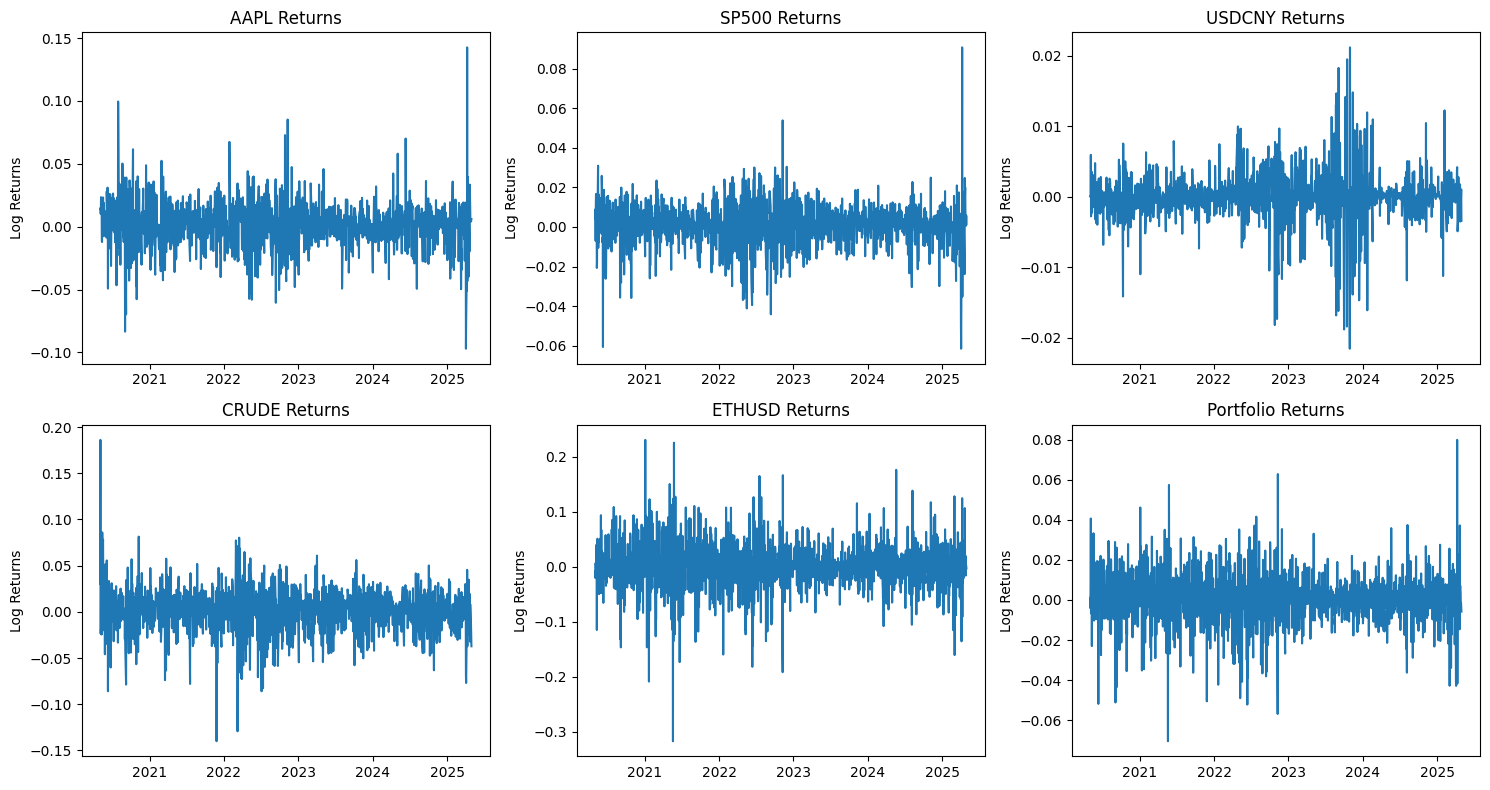

In [62]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].plot(AAPL.index, AAPL['return'])
axes[0, 0].set_title('AAPL Returns')
axes[0, 0].set_ylabel('Log Returns')

axes[0, 1].plot(SP500.index, SP500['return'])
axes[0, 1].set_title('SP500 Returns')
axes[0, 1].set_ylabel('Log Returns')

axes[0, 2].plot(USDCNY.index, USDCNY['return'])
axes[0, 2].set_title('USDCNY Returns')
axes[0, 2].set_ylabel('Log Returns')

axes[1, 0].plot(CRUDE.index, CRUDE['return'])
axes[1, 0].set_title('CRUDE Returns')
axes[1, 0].set_ylabel('Log Returns')

axes[1, 1].plot(ETHUSD.index, ETHUSD['return'])
axes[1, 1].set_title('ETHUSD Returns')
axes[1, 1].set_ylabel('Log Returns')

axes[1, 2].plot(portfolio.index, portfolio['return'])
axes[1, 2].set_title('Portfolio Returns')
axes[1, 2].set_ylabel('Log Returns')

plt.tight_layout()
plt.show()

Volatility clustering can be observed as the amplitude of return varies over time — periods of large returns (in absolute value) tend to be followed by further large returns, and calm periods cluster similarly.

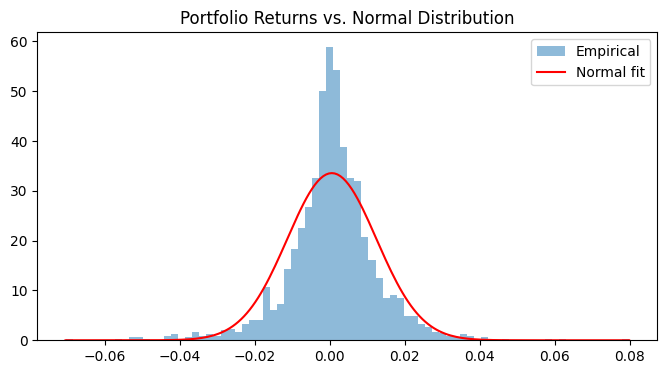

In [13]:
r = portfolio['return'].dropna()
x = np.linspace(r.min(), r.max(), 200)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(r, bins=80, density=True, alpha=0.5, label='Empirical')
ax.plot(x, stats.norm.pdf(x, r.mean(), r.std()), 'r-', label='Normal fit')
ax.set_title('Portfolio Returns vs. Normal Distribution')
ax.legend()
plt.show()


The empirical distribution shows a taller, narrower central peak and visibly heavier tails compared to the fitted normal curve. 

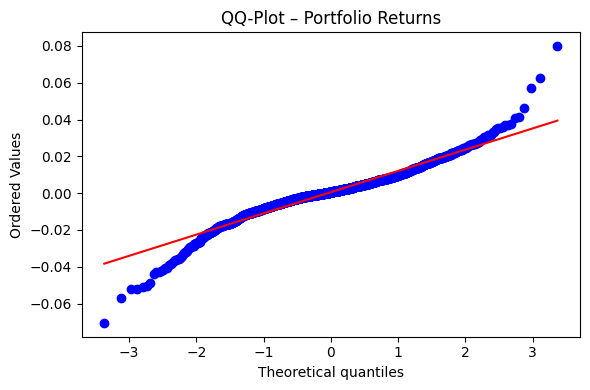

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
stats.probplot(portfolio['return'].dropna(), dist="norm", plot=ax)
ax.set_title('QQ-Plot – Portfolio Returns')
plt.tight_layout()
plt.show()

QQ-plot shows evidence of heavy tails in distributions with points in the upper-right tail rise above the line and points in the lower-left tail fall below the line.

In [ ]:
from scipy.stats import jarque_bera

stat, p = jarque_bera(portfolio['return'].dropna())
print(f"JB statistic: {stat:.2f},  p-value: {p:.6f}")

JB statistic: 1557.45,  p-value: 0.000000


JB statistic of 1557.45 (p-value ≈ 0) rejects the null hypothesis of normality. 

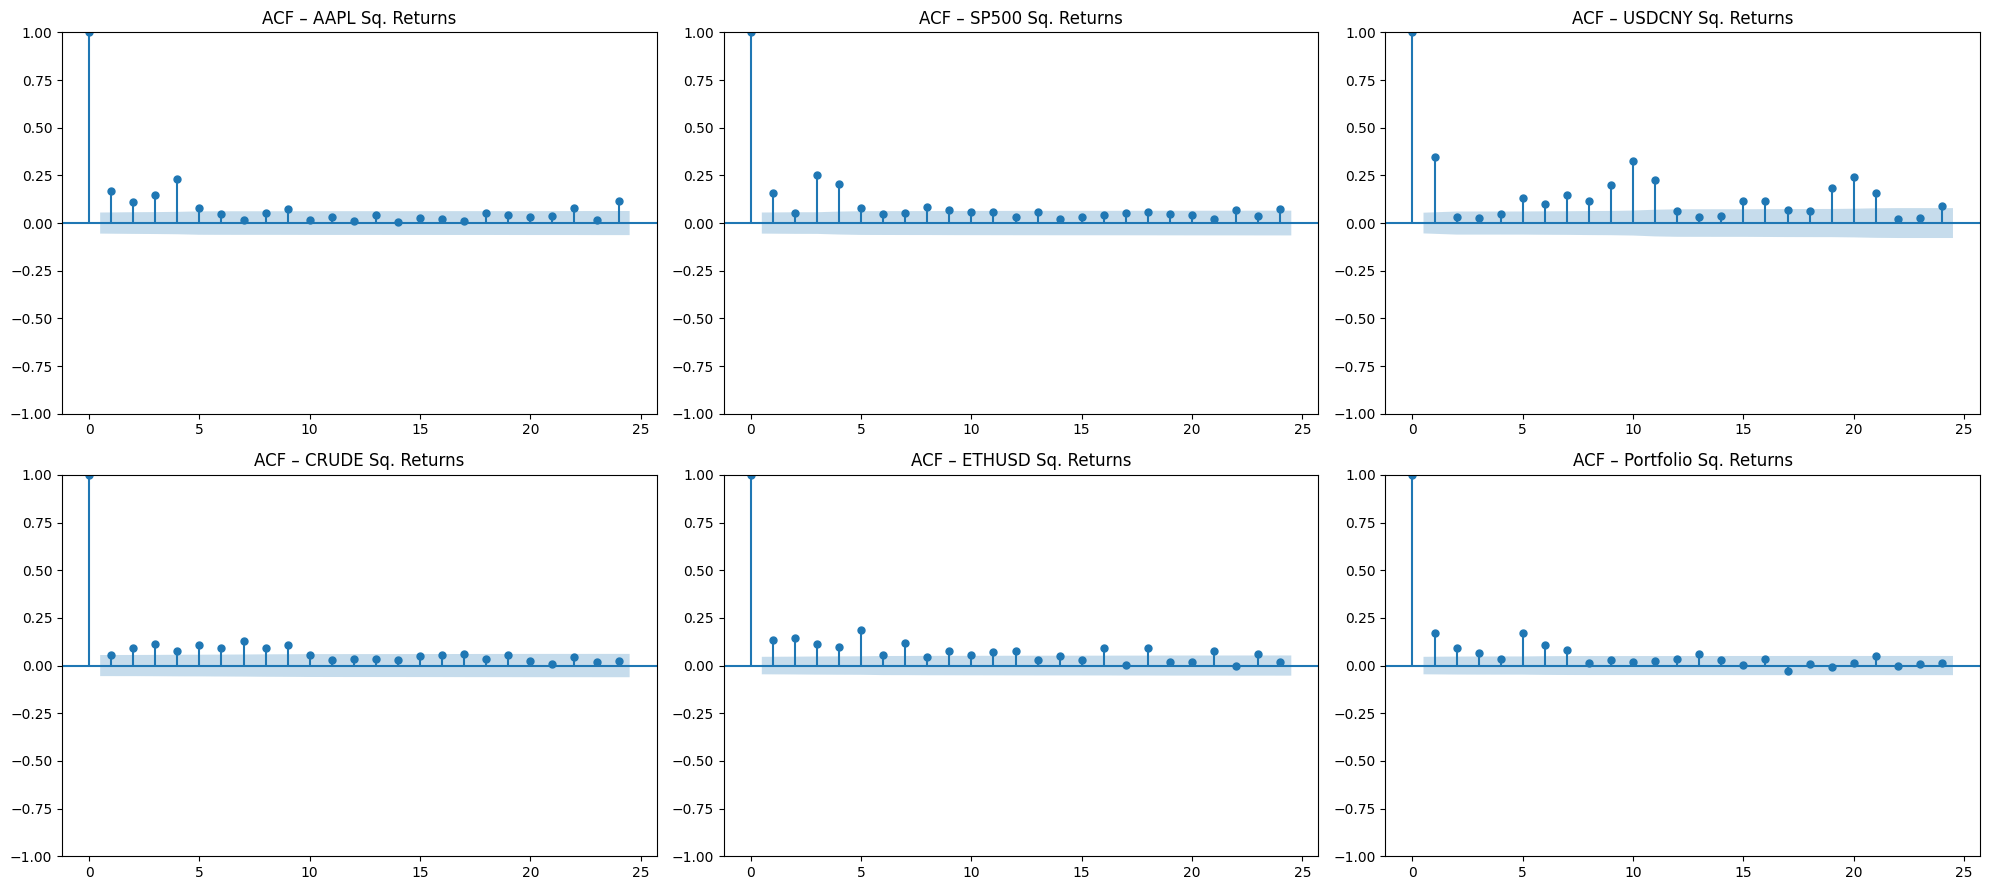

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(20, 9))

plot_acf((AAPL['return']**2).dropna(),      lags=24, ax=axes[0, 0], title='ACF – AAPL Sq. Returns')
plot_acf((SP500['return']**2).dropna(),     lags=24, ax=axes[0, 1], title='ACF – SP500 Sq. Returns')
plot_acf((USDCNY['return']**2).dropna(),    lags=24, ax=axes[0, 2], title='ACF – USDCNY Sq. Returns')
plot_acf((CRUDE['return']**2).dropna(),     lags=24, ax=axes[1, 0], title='ACF – CRUDE Sq. Returns')
plot_acf((ETHUSD['return']**2).dropna(),    lags=24, ax=axes[1, 1], title='ACF – ETHUSD Sq. Returns')
plot_acf((portfolio['return']**2).dropna(), lags=24, ax=axes[1, 2], title='ACF – Portfolio Sq. Returns')

plt.tight_layout()
plt.show()

The portfolio shows evidence of ARCH effects as presented by the autocorrelations of squared returns above.

In [23]:
# LM-ARCH test on portfolio returns
# H0: no ARCH effects (all lag coefficients = 0)
stat, p, _, _ = het_arch(portfolio['return'].dropna(), nlags=5)
print(f"LM statistic: {stat:.3f},  p-value: {p:.4f}")


LM statistic: 111.761,  p-value: 0.0000


LM test statistics of 111.761 (p-value ≈ 0) also rejects the “no ARCH” hypothesis.

In [30]:
# split data into in-sample and out-of-sample, out-of-sample used only for forcasting
portfolio_full = portfolio

portfolio = portfolio[:'2024-04-30']

#### 2. Estimating GARCH models

##### 2.1 ARCH(1)

In [65]:
# ARCH(1)
model_arch1 = arch_model(portfolio['return'].dropna(), vol='ARCH', p=1, rescale=False)
results_arch1 = model_arch1.fit(disp='off')
print(results_arch1.summary())

                      Constant Mean - ARCH Model Results                      
Dep. Variable:                 return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:                4397.72
Distribution:                  Normal   AIC:                          -8789.44
Method:            Maximum Likelihood   BIC:                          -8773.58
                                        No. Observations:                 1460
Date:                Wed, Jun 03 2026   Df Residuals:                     1459
Time:                        08:51:12   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu         7.5908e-04  3.084e-04      2.461  1.385e-02 [1.

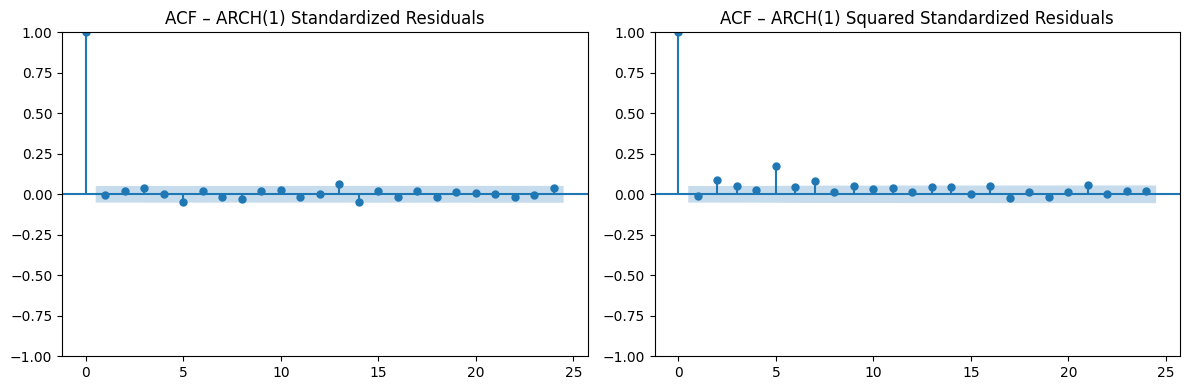

In [66]:
# ACF plot for STANDARDIZED RESIDUALS, SQUARED STANDARDIZED RESIDUALS with 95% CI
std_resid_arch1 = results_arch1.resid / results_arch1.conditional_volatility

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(std_resid_arch1.dropna(), lags=24, ax=axes[0], title='ACF – ARCH(1) Standardized Residuals')
plot_acf(std_resid_arch1.dropna()**2, lags=24, ax=axes[1], title='ACF – ARCH(1) Squared Standardized Residuals')

plt.tight_layout()
plt.show()

In [67]:
# Ljung-Box test for autocorrelation of STANDARDIZED RESIDUALS
acorr_ljungbox(
    (results_arch1.resid / results_arch1.conditional_volatility),
    lags=[5, 10, 15, 20],
    return_df=True
)

,lb_stat,lb_pvalue
5,6.113912,0.295292
10,9.871303,0.451856
15,21.073929,0.134484
20,22.944082,0.291549


In [68]:
# Ljung-Box test for autocorrelation of SQUARED STANDARDIZED RESIDUALS
acorr_ljungbox(
    (results_arch1.resid / results_arch1.conditional_volatility)**2,
    lags=[5, 10, 15, 20],
    return_df=True
)

,lb_stat,lb_pvalue
5,59.545920,1.508536e-11
10,78.888389,8.288221e-13
15,87.782578,2.566197e-12
20,93.319314,1.937135e-11


In [69]:
# LM test for remaining ARCH effects
resid_std = (results_arch1.resid / results_arch1.conditional_volatility)
arch_test_results = het_arch(resid_std, nlags=5)

print(f"LM Statistic: {arch_test_results[0]:.3f}")
print(f"p-value: {arch_test_results[1]:.3f}")

LM Statistic: 56.772
p-value: 0.000


##### 2.2 ARCH(2)

In [70]:
# ARCH(2)
model_arch2 = arch_model(portfolio['return'].dropna(), vol='ARCH', p=2, rescale=False)
results_arch2 = model_arch2.fit(disp='off')
print(results_arch2.summary())

                      Constant Mean - ARCH Model Results                      
Dep. Variable:                 return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:                4408.34
Distribution:                  Normal   AIC:                          -8808.68
Method:            Maximum Likelihood   BIC:                          -8787.53
                                        No. Observations:                 1460
Date:                Wed, Jun 03 2026   Df Residuals:                     1459
Time:                        08:51:13   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu         8.5194e-04  3.071e-04      2.774  5.542e-03 [2.

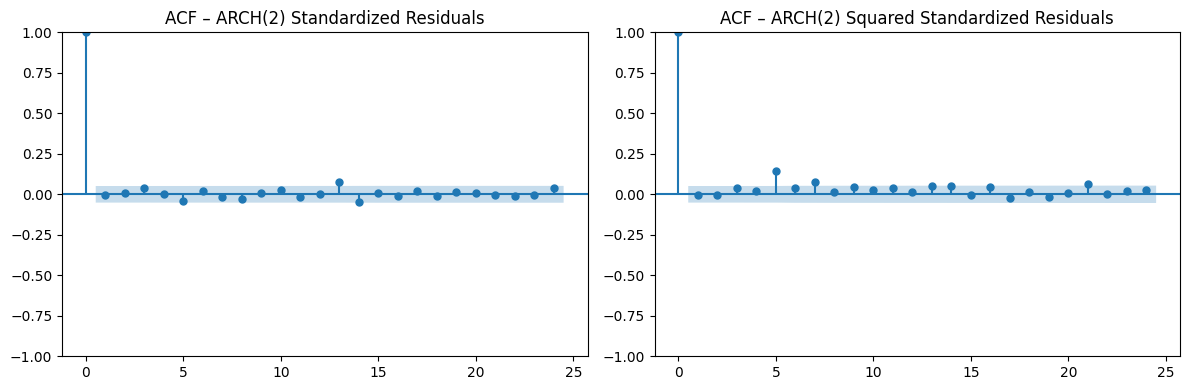

In [71]:
# ACF plot for STANDARDIZED RESIDUALS, SQUARED STANDARDIZED RESIDUALS with 95% CI
std_resid_arch2 = results_arch2.resid / results_arch2.conditional_volatility

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(std_resid_arch2.dropna(), lags=24, ax=axes[0], title='ACF – ARCH(2) Standardized Residuals')
plot_acf(std_resid_arch2.dropna()**2, lags=24, ax=axes[1], title='ACF – ARCH(2) Squared Standardized Residuals')

plt.tight_layout()
plt.show()

In [72]:
# Ljung-Box test for autocorrelation of STANDARDIZED RESIDUALS
acorr_ljungbox(
    (results_arch2.resid / results_arch2.conditional_volatility),
    lags=[5, 10, 15, 20],
    return_df=True
)

,lb_stat,lb_pvalue
5,4.891100,0.429315
10,8.471247,0.582907
15,20.709949,0.146355
20,21.999669,0.340529


In [73]:
# Ljung-Box test for autocorrelation of SQUARED STANDARDIZED RESIDUALS
acorr_ljungbox(
    (results_arch2.resid / results_arch2.conditional_volatility)**2,
    lags=[5, 10, 15, 20],
    return_df=True
)

,lb_stat,lb_pvalue
5,33.658229,2.784647e-06
10,49.077067,3.942899e-07
15,58.620315,4.347650e-07
20,63.239986,2.219074e-06


In [74]:
# LM test for remaining ARCH effects
resid_std = (results_arch2.resid / results_arch2.conditional_volatility)
arch_test_results = het_arch(resid_std, nlags=5)

print(f"LM Statistic: {arch_test_results[0]:.3f}")
print(f"p-value: {arch_test_results[1]:.3f}")

LM Statistic: 34.380
p-value: 0.000


##### 2.3 ARCH(5)

In [75]:
# ARCH(5)
model_arch5 = arch_model(portfolio['return'].dropna(), vol='ARCH', p=5, rescale=False)
results_arch5 = model_arch5.fit(disp='off')
print(results_arch5.summary())

                      Constant Mean - ARCH Model Results                      
Dep. Variable:                 return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:                4434.86
Distribution:                  Normal   AIC:                          -8855.72
Method:            Maximum Likelihood   BIC:                          -8818.72
                                        No. Observations:                 1460
Date:                Wed, Jun 03 2026   Df Residuals:                     1459
Time:                        08:51:13   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu         8.1539e-04  3.033e-04      2.688  7.185e-03 [2.

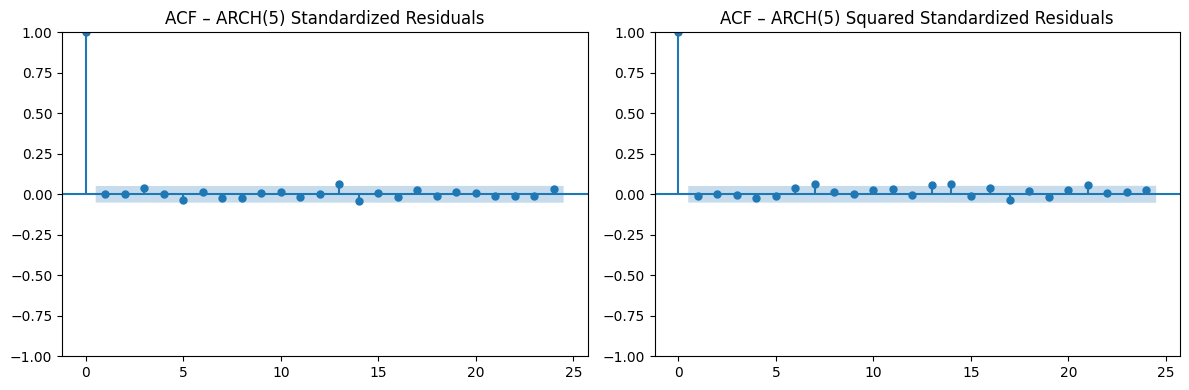

In [76]:
# ACF plot for STANDARDIZED RESIDUALS, SQUARED STANDARDIZED RESIDUALS with 95% CI
std_resid_arch5 = results_arch5.resid / results_arch5.conditional_volatility

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(std_resid_arch5.dropna(), lags=24, ax=axes[0], title='ACF – ARCH(5) Standardized Residuals')
plot_acf(std_resid_arch5.dropna()**2, lags=24, ax=axes[1], title='ACF – ARCH(5) Squared Standardized Residuals')

plt.tight_layout()
plt.show()

In [77]:
# Ljung-Box test for autocorrelation of STANDARDIZED RESIDUALS
acorr_ljungbox(
    (results_arch5.resid / results_arch5.conditional_volatility),
    lags=[5, 10, 15, 20],
    return_df=True
)

,lb_stat,lb_pvalue
5,3.548890,0.616003
10,5.632481,0.845138
15,15.486716,0.416959
20,17.234295,0.637712


In [78]:
# Ljung-Box test for autocorrelation of SQUARED STANDARDIZED RESIDUALS
acorr_ljungbox(
    (results_arch5.resid / results_arch5.conditional_volatility)**2,
    lags=[5, 10, 15, 20],
    return_df=True
)

,lb_stat,lb_pvalue
5,1.133265,0.951117
10,10.701926,0.381207
15,23.121297,0.081598
20,29.017734,0.087411


In [79]:
# LM test for remaining ARCH effects
resid_std = (results_arch5.resid / results_arch5.conditional_volatility)
arch_test_results = het_arch(resid_std, nlags=5)

print(f"LM Statistic: {arch_test_results[0]:.3f}")
print(f"p-value: {arch_test_results[1]:.3f}")

LM Statistic: 1.119
p-value: 0.952


##### 2.4 GARCH(1,1)

In [41]:
# GARCH(1,1)
model_garch11 = arch_model(portfolio['return'].dropna(), vol='GARCH', p=1, q=1, rescale=False)
results_garch11 = model_garch11.fit(disp='off')
print(results_garch11.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                4465.19
Distribution:                  Normal   AIC:                          -8922.39
Method:            Maximum Likelihood   BIC:                          -8901.24
                                        No. Observations:                 1460
Date:                Fri, Jun 05 2026   Df Residuals:                     1459
Time:                        20:07:52   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu         7.3120e-04  2.523e-04      2.898  3.757e-03 [2.

In the estimated GARCH(1,1) model, all four parameters are statistically significant, signs are correct. 
Mu is the average daily portfolio log-return. 
Omega is the long-run contribution to variance. The annualised unconditional long-run variance implied by the model approx. 19%. 
Alpha measures how much a large return shock at t-1 immediately elevates today's variance. A value of 0.05 indicates shocks have a moderate immediate impact. 
Beta Measures how much of yesterday's conditional variance carries over to today. At 0.93, volatility is highly persistent — a shock to variance takes a long time to decay back to the unconditional level. 
A sum of alpha and beta is less than 1, matches the requirement as a mean reverting variance process. 


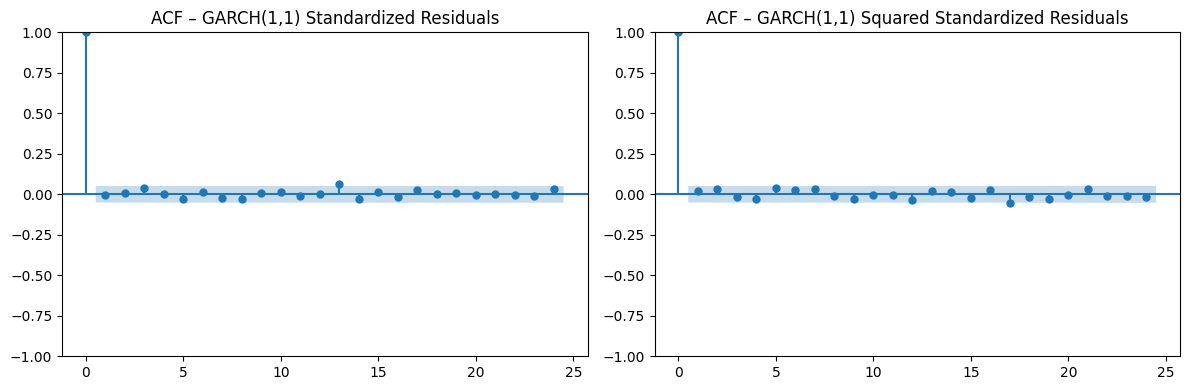

In [81]:
# ACF plot for STANDARDIZED RESIDUALS, SQUARED STANDARDIZED RESIDUALS with 95% CI
std_resid_garch11 = results_garch11.resid / results_garch11.conditional_volatility

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(std_resid_garch11.dropna(), lags=24, ax=axes[0], title='ACF – GARCH(1,1) Standardized Residuals')
plot_acf(std_resid_garch11.dropna()**2, lags=24, ax=axes[1], title='ACF – GARCH(1,1) Squared Standardized Residuals')

plt.tight_layout()
plt.show()

In [82]:
# Ljung-Box test for autocorrelation of STANDARDIZED RESIDUALS
acorr_ljungbox(
    (results_garch11.resid / results_garch11.conditional_volatility),
    lags=[5, 10, 15, 20],
    return_df=True
)

,lb_stat,lb_pvalue
5,3.474358,0.627271
10,6.258356,0.793110
15,14.484394,0.489154
20,15.975463,0.718145


all p-values are above 0.05. We fail to reject H₀ of no serial correlation in standardized residuals at all lags. The mean equation (constant mean) is correctly specified — no autocorrelation structure in returns is left unexplained. 

In [83]:
# Ljung-Box test for autocorrelation of SQUARED STANDARDIZED RESIDUALS
acorr_ljungbox(
    (results_garch11.resid / results_garch11.conditional_volatility)**2,
    lags=[5, 10, 15, 20],
    return_df=True
)

,lb_stat,lb_pvalue
5,6.458981,0.264083
10,10.309133,0.413803
15,13.910527,0.532326
20,21.427917,0.372342


all p-values comfortably above 0.05. We fail to reject H₀ of no autocorrelation in squared residuals. GARCH(1,1) has successfully absorbed the volatility dynamics — squared residuals is white noise, meaning no predictable variance structure remains in the residuals.

In [84]:
# LM test for remaining ARCH effects
resid_std = (results_garch11.resid / results_garch11.conditional_volatility)
arch_test_results = het_arch(resid_std, nlags=5)

print(f"LM Statistic: {arch_test_results[0]:.3f}")
print(f"p-value: {arch_test_results[1]:.3f}")

LM Statistic: 7.050
p-value: 0.217


p = 0.217 means we fail to reject H₀ of no remaining ARCH effects.

##### 2.4b GARCH(1,1) – Student-t distribution

In [83]:
# GARCH(1,1) – Student-t innovations
model_garch11t = arch_model(portfolio['return'].dropna(), vol='GARCH', p=1, q=1,
                            dist='t', rescale=False)
results_garch11t = model_garch11t.fit(disp='off')
print(results_garch11t.summary())


                        Constant Mean - GARCH Model Results                         
Dep. Variable:                       return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:                3393.30
Distribution:      Standardized Student's t   AIC:                          -6776.61
Method:                  Maximum Likelihood   BIC:                          -6750.18
                                              No. Observations:                 1460
Date:                      Fri, Jun 05 2026   Df Residuals:                     1459
Time:                              20:37:30   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

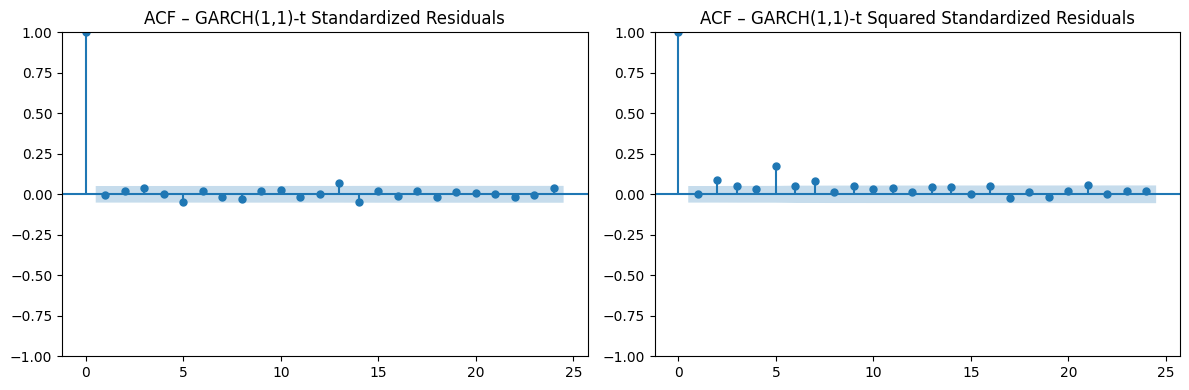

In [84]:
std_resid_garch11t = results_garch11t.resid / results_garch11t.conditional_volatility

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(std_resid_garch11t.dropna(),    lags=24, ax=axes[0], title='ACF – GARCH(1,1)-t Standardized Residuals')
plot_acf(std_resid_garch11t.dropna()**2, lags=24, ax=axes[1], title='ACF – GARCH(1,1)-t Squared Standardized Residuals')
plt.tight_layout()
plt.show()


In [85]:
# Ljung-Box on standardized residuals
print("LB on z_t:")
display(acorr_ljungbox(std_resid_garch11t.dropna(), lags=[5, 10, 15, 20], return_df=True))

# Ljung-Box on squared standardized residuals
print("LB on z_t^2:")
display(acorr_ljungbox(std_resid_garch11t.dropna()**2, lags=[5, 10, 15, 20], return_df=True))

# LM-ARCH test
lm_stat, lm_p, _, _ = het_arch(std_resid_garch11t.dropna(), nlags=5)
print(f"LM-ARCH statistic: {lm_stat:.3f},  p-value: {lm_p:.3f}")


LB on z_t:


,lb_stat,lb_pvalue
5,6.005493,0.305685
10,9.798977,0.458303
15,21.145677,0.132239
20,23.058762,0.285918


LB on z_t^2:


,lb_stat,lb_pvalue
5,62.620090,3.489352e-12
10,82.767176,1.436847e-13
15,91.570174,5.048155e-13
20,97.028256,4.269659e-12


LM-ARCH statistic: 58.576,  p-value: 0.000


##### 2.5 GARCH(2,1)

In [85]:
# GARCH(2,1)
model_garch21 = arch_model(portfolio['return'].dropna(), vol='GARCH', p=2, q=1, rescale=False)
results_garch21 = model_garch21.fit(disp='off')
print(results_garch21.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                4463.38
Distribution:                  Normal   AIC:                          -8916.76
Method:            Maximum Likelihood   BIC:                          -8890.32
                                        No. Observations:                 1460
Date:                Wed, Jun 03 2026   Df Residuals:                     1459
Time:                        08:51:14   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu         7.1202e-04  2.737e-04      2.601  9.286e-03 [1.

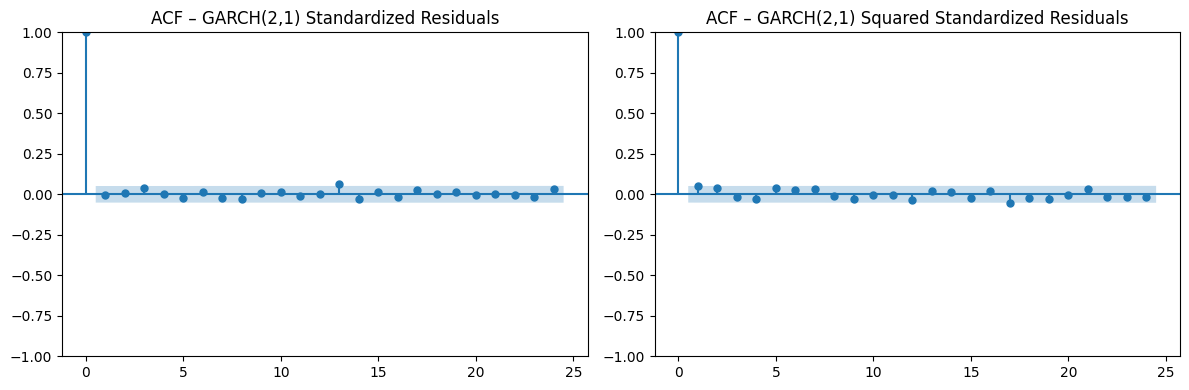

In [86]:
# ACF plot for STANDARDIZED RESIDUALS, SQUARED STANDARDIZED RESIDUALS with 95% CI
std_resid_garch21 = results_garch21.resid / results_garch21.conditional_volatility

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(std_resid_garch21.dropna(), lags=24, ax=axes[0], title='ACF – GARCH(2,1) Standardized Residuals')
plot_acf(std_resid_garch21.dropna()**2, lags=24, ax=axes[1], title='ACF – GARCH(2,1) Squared Standardized Residuals')

plt.tight_layout()
plt.show()

In [87]:
# Ljung-Box test for autocorrelation of STANDARDIZED RESIDUALS
acorr_ljungbox(
    (results_garch21.resid / results_garch21.conditional_volatility),
    lags=[5, 10, 15, 20],
    return_df=True
)

,lb_stat,lb_pvalue
5,3.407979,0.637355
10,6.237888,0.794897
15,14.463858,0.490679
20,15.998118,0.716741


In [88]:
# Ljung-Box test for autocorrelation of SQUARED STANDARDIZED RESIDUALS
acorr_ljungbox(
    (results_garch21.resid / results_garch21.conditional_volatility)**2,
    lags=[5, 10, 15, 20],
    return_df=True
)

,lb_stat,lb_pvalue
5,9.631822,0.086365
10,13.656080,0.189265
15,16.908308,0.324375
20,24.547176,0.219307


In [89]:
# LM test for remaining ARCH effects
resid_std = (results_garch21.resid / results_garch21.conditional_volatility)
arch_test_results = het_arch(resid_std, nlags=5)

print(f"LM Statistic: {arch_test_results[0]:.3f}")
print(f"p-value: {arch_test_results[1]:.3f}")

LM Statistic: 10.418
p-value: 0.064


##### 2.6 GARCH(1,2)

In [90]:
# GARCH(1,2)
model_garch12 = arch_model(portfolio['return'].dropna(), vol='GARCH', p=1, q=2, rescale=False)
results_garch12 = model_garch12.fit(disp='off')
print(results_garch12.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                4466.95
Distribution:                  Normal   AIC:                          -8923.91
Method:            Maximum Likelihood   BIC:                          -8897.48
                                        No. Observations:                 1460
Date:                Wed, Jun 03 2026   Df Residuals:                     1459
Time:                        08:51:15   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu         7.0748e-04  1.220e-04      5.798  6.697e-09 [4.

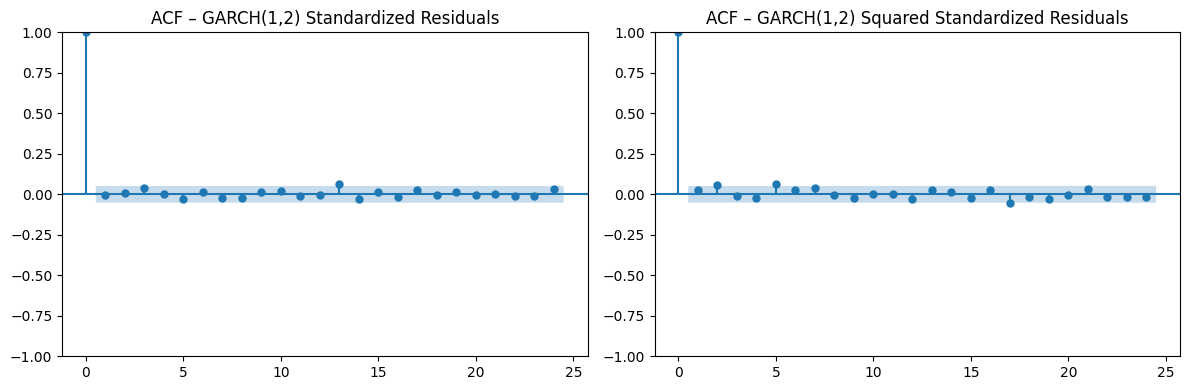

In [91]:
# ACF plot for STANDARDIZED RESIDUALS, SQUARED STANDARDIZED RESIDUALS with 95% CI
std_resid_garch12 = results_garch12.resid / results_garch12.conditional_volatility

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(std_resid_garch12.dropna(), lags=24, ax=axes[0], title='ACF – GARCH(1,2) Standardized Residuals')
plot_acf(std_resid_garch12.dropna()**2, lags=24, ax=axes[1], title='ACF – GARCH(1,2) Squared Standardized Residuals')

plt.tight_layout()
plt.show()

In [92]:
# Ljung-Box test for autocorrelation of STANDARDIZED RESIDUALS
acorr_ljungbox(
    (results_garch12.resid / results_garch12.conditional_volatility),
    lags=[5, 10, 15, 20],
    return_df=True
)

,lb_stat,lb_pvalue
5,3.622260,0.604974
10,6.541090,0.767942
15,14.844830,0.462651
20,16.465971,0.687328


In [93]:
# Ljung-Box test for autocorrelation of SQUARED STANDARDIZED RESIDUALS
acorr_ljungbox(
    (results_garch12.resid / results_garch12.conditional_volatility)**2,
    lags=[5, 10, 15, 20],
    return_df=True
)

,lb_stat,lb_pvalue
5,12.412429,0.029553
10,16.700429,0.081261
15,19.891955,0.176117
20,27.402882,0.124305


In [94]:
# LM test for remaining ARCH effects
resid_std = (results_garch12.resid / results_garch12.conditional_volatility)
arch_test_results = het_arch(resid_std, nlags=5)

print(f"LM Statistic: {arch_test_results[0]:.3f}")
print(f"p-value: {arch_test_results[1]:.3f}")

LM Statistic: 13.380
p-value: 0.020


##### 2.7 EGARCH(1,1)

In [34]:
# EGARCH(1,1,2)
model_egarch11 = arch_model(portfolio['return'].dropna(), vol='EGARCH', p=1, o=2, q=1, rescale=False)
results_egarch11 = model_egarch11.fit(disp='off')
print(results_egarch11.summary())

                     Constant Mean - EGARCH Model Results                     
Dep. Variable:                 return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:                4490.02
Distribution:                  Normal   AIC:                          -8968.03
Method:            Maximum Likelihood   BIC:                          -8936.32
                                        No. Observations:                 1460
Date:                Fri, Jun 05 2026   Df Residuals:                     1459
Time:                        19:54:22   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu         5.6945e-04  2.394e-04      2.378  1.738e-02 [1.

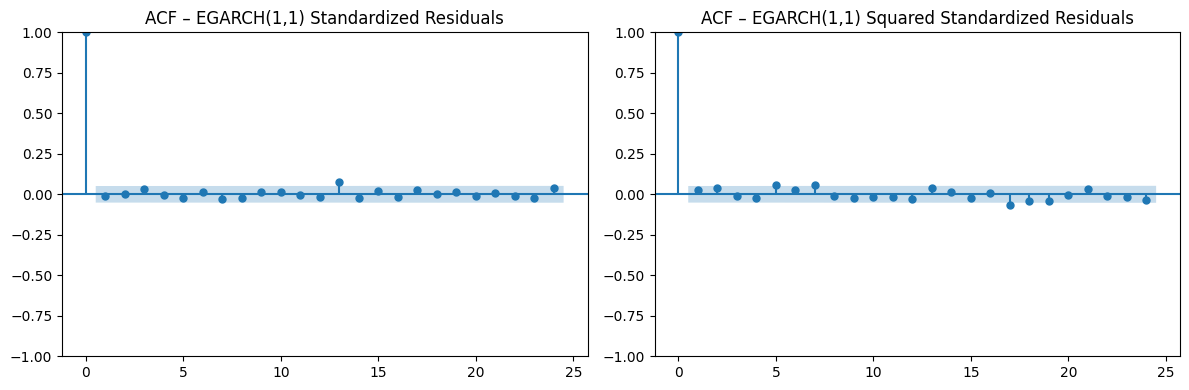

In [35]:
# ACF plot for STANDARDIZED RESIDUALS, SQUARED STANDARDIZED RESIDUALS with 95% CI
std_resid_egarch11 = results_egarch11.resid / results_egarch11.conditional_volatility

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(std_resid_egarch11.dropna(), lags=24, ax=axes[0], title='ACF – EGARCH(1,1) Standardized Residuals')
plot_acf(std_resid_egarch11.dropna()**2, lags=24, ax=axes[1], title='ACF – EGARCH(1,1) Squared Standardized Residuals')

plt.tight_layout()
plt.show()

In [36]:
# Ljung-Box test for autocorrelation of STANDARDIZED RESIDUALS
acorr_ljungbox(
    (results_egarch11.resid / results_egarch11.conditional_volatility),
    lags=[5, 10, 15, 20],
    return_df=True
)

,lb_stat,lb_pvalue
5,2.496005,0.777097
10,5.570529,0.849964
15,15.577879,0.410647
20,17.399543,0.626898


In [37]:
# Ljung-Box test for autocorrelation of SQUARED STANDARDIZED RESIDUALS
acorr_ljungbox(
    (results_egarch11.resid / results_egarch11.conditional_volatility)**2,
    lags=[5, 10, 15, 20],
    return_df=True
)

,lb_stat,lb_pvalue
5,8.711680,0.121132
10,15.405066,0.117977
15,20.371277,0.158148
20,31.741804,0.046128


In [39]:
# LM test for remaining ARCH effects
resid_std = (results_egarch11.resid / results_egarch11.conditional_volatility)
arch_test_results = het_arch(resid_std, nlags=5)

print(f"LM Statistic: {arch_test_results[0]:.3f}")
print(f"p-value: {arch_test_results[1]:.3f}")

LM Statistic: 9.433
p-value: 0.093


##### 2.8 Model Summary

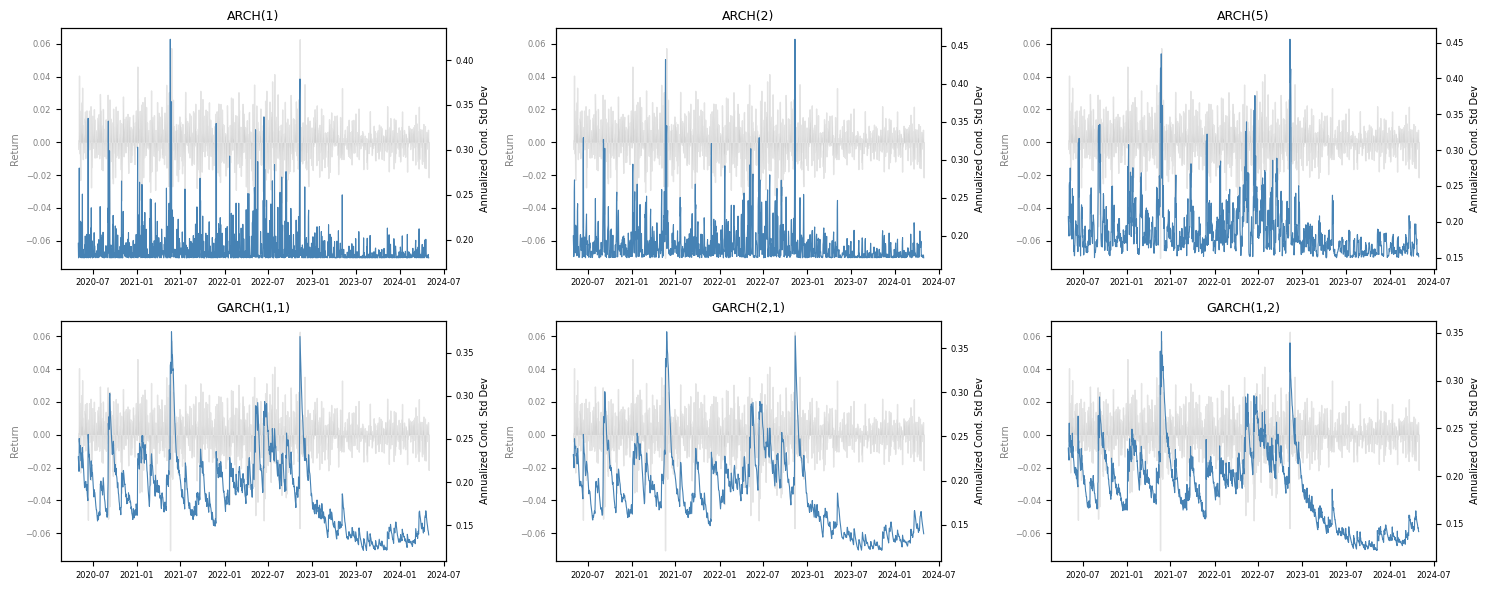

In [100]:
# Conditional standard deviation – all models overlaid on portfolio returns
models = [
    (results_arch1,   'ARCH(1)'),
    (results_arch2,   'ARCH(2)'),
    (results_arch5,   'ARCH(5)'),
    (results_garch11, 'GARCH(1,1)'),
    (results_garch21, 'GARCH(2,1)'),
    (results_garch12, 'GARCH(1,2)'),
]

returns = portfolio['return'].dropna()
fig, axes = plt.subplots(2, 3, figsize=(15, 6))

for ax, (res, label) in zip(axes.flat, models):
    ax1 = ax
    ax1.fill_between(returns.index, returns, alpha=0.2, color='grey')
    ax1.set_ylabel('Return', fontsize=7, color='grey')
    ax1.tick_params(axis='y', labelcolor='grey', labelsize=6)
    ax1.tick_params(axis='x', labelsize=6)

    ax2 = ax1.twinx()
    ax2.plot(res.conditional_volatility.index, np.sqrt(252) * res.conditional_volatility,
             color='steelblue', linewidth=0.8)
    ax2.set_ylabel('Annualized Cond. Std Dev', fontsize=7)
    ax2.tick_params(axis='y', labelsize=6)
    ax.set_title(label, fontsize=9)

plt.tight_layout()
plt.show()

In [101]:
# Model comparison – AIC and BIC
model_names = ['ARCH(1)', 'ARCH(2)', 'ARCH(5)', 'GARCH(1,1)', 'GARCH(2,1)', 'GARCH(1,2)']
results_list = [results_arch1, results_arch2, results_arch5, results_garch11, results_garch21, results_garch12]

comparison = pd.DataFrame({
    'AIC': [r.aic for r in results_list],
    'BIC': [r.bic for r in results_list],
}, index=model_names)

print(comparison.to_string())
print(f"\nBest AIC: {comparison['AIC'].idxmin()}  ({comparison['AIC'].min():.2f})")
print(f"Best BIC: {comparison['BIC'].idxmin()}  ({comparison['BIC'].min():.2f})")

                    AIC          BIC
ARCH(1)    -8789.440786 -8773.582211
ARCH(2)    -8808.678035 -8787.533268
ARCH(5)    -8855.722380 -8818.719038
GARCH(1,1) -8922.377516 -8901.232749
GARCH(2,1) -8916.755445 -8890.324486
GARCH(1,2) -8923.906297 -8897.475338

Best AIC: GARCH(1,2)  (-8923.91)
Best BIC: GARCH(1,1)  (-8901.23)


#### 3. Diagnostics of estimated models

In [42]:
# an example of using R's rugarch package in python
# more info about rpy2 library: https://rpy2.github.io/doc/v3.6.x/html/introduction.html
# more info about rugarch library: https://cran.r-project.org/web/packages/rugarch/index.html

# importing python libraries
import rpy2 
import rpy2.robjects as robjects
from rpy2.robjects.packages import importr, data
from rpy2.robjects.vectors import ListVector, BoolVector

# loading R packages
utils = importr('utils')
base = importr('base')

# Installation of R packages (remove/comment out if already installed)
utils.chooseCRANmirror(ind=1)
# utils.install_packages('nloptr')
# utils.install_packages('rugarch')

# loading R packages
# stats = importr('stats')
rugarch = importr('rugarch')

# creating object with return
returns = robjects.FloatVector(portfolio['return'].dropna())

# model specification
spec = rugarch.ugarchspec(
    variance_model = ListVector({
        'model': 'sGARCH',
        'garchOrder': robjects.IntVector([1, 1])
    }),
    mean_model = ListVector({
        'armaOrder': robjects.IntVector([0, 0]),
        'include.mean': BoolVector([False])
    }),
    distribution_model = 'norm')

# fitting the model
m1 = rugarch.ugarchfit(spec = spec, data = returns)

# printing report with the model
base.print(m1)


*---------------------------------*
*          GARCH Model Fit        *
*---------------------------------*

Conditional Variance Dynamics 	
-----------------------------------
GARCH Model	: sGARCH(1,1)
Mean Model	: ARFIMA(0,0,0)
Distribution	: norm 

Optimal Parameters
------------------------------------
        Estimate  Std. Error   t value Pr(>|t|)
omega   0.000000    0.000000   0.49775  0.61866
alpha1  0.023147    0.001251  18.50870  0.00000
beta1   0.975414    0.001515 643.96910  0.00000

Robust Standard Errors:
        Estimate  Std. Error    t value Pr(>|t|)
omega   0.000000    0.000002   0.082479 0.934266
alpha1  0.023147    0.005882   3.935234 0.000083
beta1   0.975414    0.005888 165.669367 0.000000

LogLikelihood : 4473.205 

Information Criteria
------------------------------------
                    
Akaike       -6.1236
Bayes        -6.1127
Shibata      -6.1236
Hannan-Quinn -6.1195

Weighted Ljung-Box Test on Standardized Residuals
------------------------------------

<rpy2.robjects.methods.RS4 object at 0x1218ba510> [25]
R classes: ('uGARCHfit',)

Nyblom parameter stability test – omega is unstable, the baseline variance level shifts across regimes, the variance floor is not constant over in-sample period. Joint statistic is also rejected driven by omega.
Sign bias test suggest that negative shocks have a lager effect than GARCH(1,1) captures, standard GARCH(1,1) misses the leverage effect — negative portfolio shocks elevate volatility more than positive shocks of equal magnitude. Joint effect statistics also confirms overall asymmetry.
Adjusted Pearson Goodness-of-Fit test results in all four groupings reject normality. Even after GARCH(1,1) removes the volatility clustering, the standardized residuals are still not normally distributed. Under a normal assumption, model can underestimate tail risk, as the distribution observes a heavier tail than a standard normal.

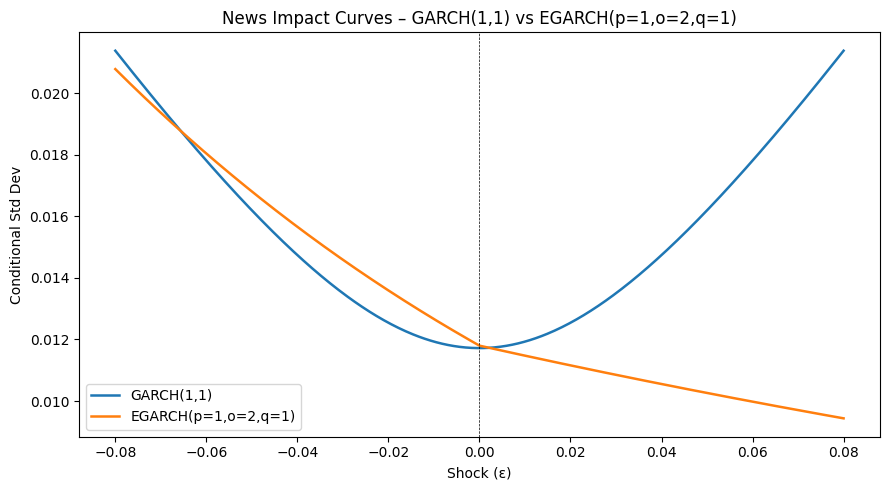

In [44]:
# News Impact Curves – GARCH(1,1) vs EGARCH(p=1,o=2,q=1)
eps = np.linspace(-0.08, 0.08, 500)

E_abs_z = np.sqrt(2 / np.pi)  # E[|z|] for standard normal

def nic_garch11(eps, params):
    omega = params['omega']
    a1, b1 = params['alpha[1]'], params['beta[1]']
    sigma2_unc = omega / (1 - a1 - b1)
    return np.sqrt(omega + a1 * eps**2 + b1 * sigma2_unc)

def nic_egarch112(eps, params):
    omega  = params['omega']
    alpha  = params['alpha[1]']
    gamma1 = params['gamma[1]']
    gamma2 = params['gamma[2]']
    beta   = params['beta[1]']
    sigma2_unc = portfolio['return'].dropna().var()   # sample variance as proxy
    z = eps / np.sqrt(sigma2_unc)
    # fix z_{t-2} = 0, vary z_{t-1} = z
    log_sigma2 = (omega + alpha * (np.abs(z) - E_abs_z)
                  + gamma1 * z + gamma2 * 0
                  + beta * np.log(sigma2_unc))
    return np.sqrt(np.exp(log_sigma2))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(eps, nic_garch11(eps, results_garch11.params), linewidth=1.8, label='GARCH(1,1)')
ax.plot(eps, nic_egarch112(eps, results_egarch11.params), linewidth=1.8, label='EGARCH(p=1,o=2,q=1)')

ax.set_xlabel('Shock (ε)')
ax.set_ylabel('Conditional Std Dev')
ax.set_title('News Impact Curves – GARCH(1,1) vs EGARCH(p=1,o=2,q=1)')
ax.legend(fontsize=10)
ax.axvline(0, color='black', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.show()


GARCH curve shows a standard symmetric U-shape, identical response to positive and negative shocks. While EGARCH curve is asymmetric — negative shocks produce higher conditional volatility than positive shocks of equal magnitude, which is the leverage effect captured by this model.

#### 4. Calculate Value-at-Risk for both in-sample and out-of-sample periods

In-sample observations : 1460
VaR 95% violations     : 71 (4.86%)  expected ~5.00%
VaR 99% violations     : 32 (2.19%)  expected ~1.00%


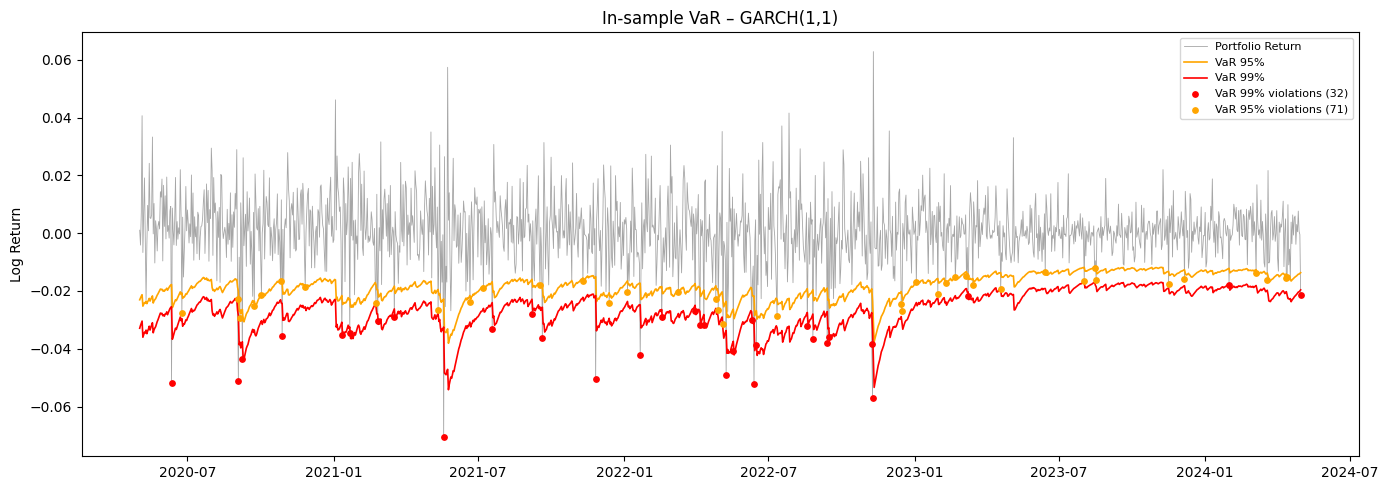

In [105]:
# In-sample VaR – GARCH(1,1)

import scipy.stats as stats

mu = results_garch11.params['mu']
cond_std = results_garch11.conditional_volatility
returns_is = portfolio['return'].dropna().reindex(cond_std.index)

var_95 = mu + stats.norm.ppf(0.05) * cond_std   # 5th percentile
var_99 = mu + stats.norm.ppf(0.01) * cond_std   # 1st percentile

violations_95 = (returns_is < var_95).sum()
violations_99 = (returns_is < var_99).sum()
n = len(returns_is)

print(f"In-sample observations : {n}")
print(f"VaR 95% violations     : {violations_95} ({violations_95/n*100:.2f}%)  expected ~5.00%")
print(f"VaR 99% violations     : {violations_99} ({violations_99/n*100:.2f}%)  expected ~1.00%")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(returns_is.index, returns_is, color='grey', linewidth=0.6, label='Portfolio Return', alpha=0.7)
ax.plot(var_95.index, var_95, color='orange', linewidth=1.2, label='VaR 95%')
ax.plot(var_99.index, var_99, color='red',    linewidth=1.2, label='VaR 99%')

ax.scatter(returns_is.index[returns_is < var_99],
           returns_is[returns_is < var_99],
           color='red', s=15, zorder=5, label=f'VaR 99% violations ({violations_99})')
ax.scatter(returns_is.index[(returns_is < var_95) & (returns_is >= var_99)],
           returns_is[(returns_is < var_95) & (returns_is >= var_99)],
           color='orange', s=15, zorder=5, label=f'VaR 95% violations ({violations_95})')

ax.set_title('In-sample VaR – GARCH(1,1)')
ax.set_ylabel('Log Return')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In-sample VaR is evaluated on the same data used for estimation. At a 95% level, Expected violations: 73. Observed: 71. The observed count is well within one standard deviation of the expected — the model is correctly calibrated at the 95% level. At a 99% level, Expected violations: 15. Observed: 32. The model is systematically underestimating the probability of very large losses.

OOS observations   : 365
VaR 95% violations : 28 (7.67%)  expected ~5.00%
VaR 99% violations : 16 (4.38%)  expected ~1.00%


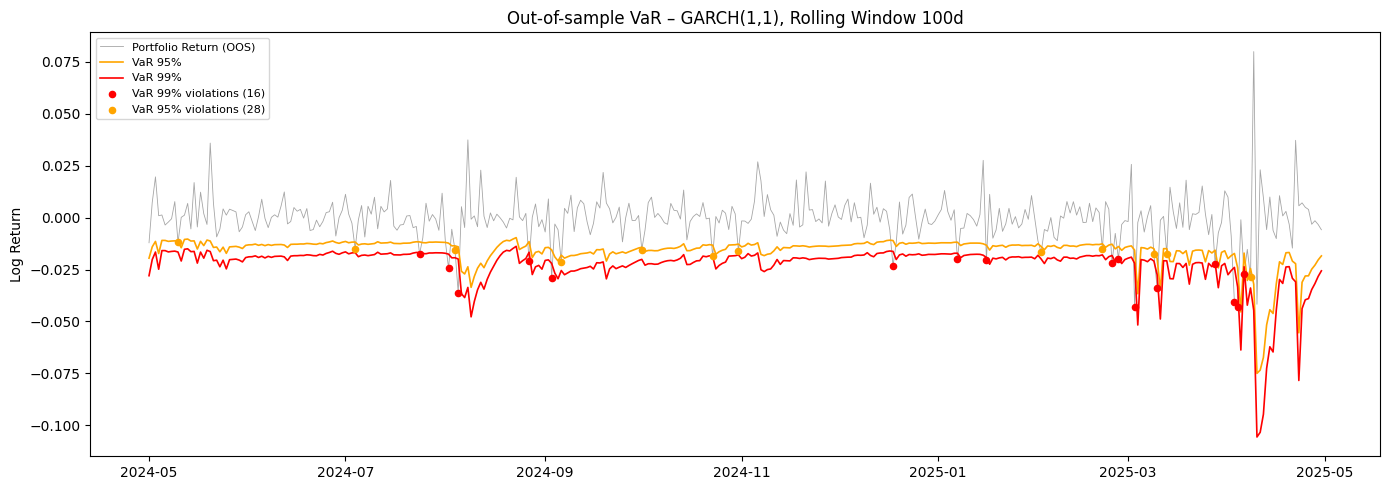

In [47]:
# Out-of-sample VaR – GARCH(1,1), rolling window 100 days, 1-step-ahead
returns_full = portfolio_full['return'].dropna()
portfolio_oos = returns_full['2024-05-01':'2025-04-30']

window = 100
var_95_oos = pd.Series(index=portfolio_oos.index, dtype=float)
var_99_oos = pd.Series(index=portfolio_oos.index, dtype=float)

for t in portfolio_oos.index:
    pos = returns_full.index.get_loc(t)
    train = returns_full.iloc[pos - window : pos]
    res = arch_model(train, vol='GARCH', p=1, q=1, rescale=False).fit(disp='off')
    mu_t  = res.params['mu']
    std_t = np.sqrt(res.forecast(horizon=1).variance.iloc[-1, 0])
    var_95_oos[t] = mu_t + stats.norm.ppf(0.05) * std_t
    var_99_oos[t] = mu_t + stats.norm.ppf(0.01) * std_t

violations_95 = (portfolio_oos < var_95_oos).sum()
violations_99 = (portfolio_oos < var_99_oos).sum()
n_oos = len(portfolio_oos)

print(f"OOS observations   : {n_oos}")
print(f"VaR 95% violations : {violations_95} ({violations_95/n_oos*100:.2f}%)  expected ~5.00%")
print(f"VaR 99% violations : {violations_99} ({violations_99/n_oos*100:.2f}%)  expected ~1.00%")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(portfolio_oos.index, portfolio_oos, color='grey', linewidth=0.6, alpha=0.7, label='Portfolio Return (OOS)')
ax.plot(var_95_oos.index, var_95_oos, color='orange', linewidth=1.2, label='VaR 95%')
ax.plot(var_99_oos.index, var_99_oos, color='red',    linewidth=1.2, label='VaR 99%')

ax.scatter(portfolio_oos.index[portfolio_oos < var_99_oos],
           portfolio_oos[portfolio_oos < var_99_oos],
           color='red', s=20, zorder=5, label=f'VaR 99% violations ({violations_99})')
ax.scatter(portfolio_oos.index[(portfolio_oos < var_95_oos) & (portfolio_oos >= var_99_oos)],
           portfolio_oos[(portfolio_oos < var_95_oos) & (portfolio_oos >= var_99_oos)],
           color='orange', s=20, zorder=5, label=f'VaR 95% violations ({violations_95})')

ax.set_title('Out-of-sample VaR – GARCH(1,1), Rolling Window 100d')
ax.set_ylabel('Log Return')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Out-of-sample value-at-risk is calculated using a rolling forward method with a 100-day window. At a 95% level, Expected violations: 18.3. Observed: 28. At a 99% level, Expected violations: 3.65. Observed: 16. The model underestimates both tail distribution and level of volatility in out-of-sample period. Possible cause is the volatility spike at the end of out-of-sample period and high persistence in the model responds slowly to the spike.